# Session 8 — Polynomial Regression, Overfitting & Regularization
---

## Question 1
**Use sklearn's `PolynomialFeatures()` to transform a dataset of mobile phone prices (features: RAM, storage) into polynomial features up to degree 2, and print the resulting feature matrix.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# Mobile Phone Dataset (small sample for clear demonstration)
# ============================================================

mobile_data = pd.DataFrame({
    'phone':    ['Redmi 12', 'Realme 11', 'Samsung M34', 'OnePlus Nord', 'iPhone 15',
                 'Vivo V30', 'Poco X6', 'Nothing Phone 2', 'Pixel 8', 'Samsung S24'],
    'ram_gb':   [4, 6, 6, 8, 8, 8, 12, 12, 12, 16],
    'storage_gb': [64, 128, 128, 128, 256, 256, 256, 256, 512, 512],
    'price_inr': [9999, 14999, 16999, 24999, 79999, 29999, 19999, 34999, 54999, 119999]
})

print("MOBILE PHONE DATASET")
print("=" * 55)
mobile_data

MOBILE PHONE DATASET


,phone,ram_gb,storage_gb,price_inr
0,Redmi 12,4,64,9999
1,Realme 11,6,128,14999
2,Samsung M34,6,128,16999
3,OnePlus Nord,8,128,24999
4,iPhone 15,8,256,79999
5,Vivo V30,8,256,29999
6,Poco X6,12,256,19999
7,Nothing Phone 2,12,256,34999
8,Pixel 8,12,512,54999
9,Samsung S24,16,512,119999


In [2]:
from sklearn.preprocessing import PolynomialFeatures

# Original features
X_original = mobile_data[['ram_gb', 'storage_gb']]

print("BEFORE PolynomialFeatures (Original)")
print("=" * 40)
print(f"Shape: {X_original.shape}")
print(f"Columns: {list(X_original.columns)}")
print(X_original.to_string(index=False))

# Transform to polynomial features (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_original)

# Get feature names
poly_feature_names = poly.get_feature_names_out(['ram_gb', 'storage_gb'])

print(f"\n\nAFTER PolynomialFeatures (Degree=2)")
print("=" * 70)
print(f"Shape: {X_poly.shape}")
print(f"New columns: {list(poly_feature_names)}")
print()

X_poly_df = pd.DataFrame(X_poly, columns=poly_feature_names)
X_poly_df

BEFORE PolynomialFeatures (Original)
Shape: (10, 2)
Columns: ['ram_gb', 'storage_gb']
 ram_gb  storage_gb
      4          64
      6         128
      6         128
      8         128
      8         256
      8         256
     12         256
     12         256
     12         512
     16         512


AFTER PolynomialFeatures (Degree=2)
Shape: (10, 5)
New columns: ['ram_gb', 'storage_gb', 'ram_gb^2', 'ram_gb storage_gb', 'storage_gb^2']



,ram_gb,storage_gb,ram_gb^2,ram_gb storage_gb,storage_gb^2
0,4.0,64.0,16.0,256.0,4096.0
1,6.0,128.0,36.0,768.0,16384.0
2,6.0,128.0,36.0,768.0,16384.0
3,8.0,128.0,64.0,1024.0,16384.0
4,8.0,256.0,64.0,2048.0,65536.0
5,8.0,256.0,64.0,2048.0,65536.0
6,12.0,256.0,144.0,3072.0,65536.0
7,12.0,256.0,144.0,3072.0,65536.0
8,12.0,512.0,144.0,6144.0,262144.0
9,16.0,512.0,256.0,8192.0,262144.0


### How Polynomial Features Work (Degree=2)

For two features $x_1$ (RAM) and $x_2$ (storage), degree=2 generates:

| Original | Polynomial (Degree 2) |
|----------|----------------------|
| $x_1, x_2$ | $x_1,\ x_2,\ x_1^2,\ x_1 \cdot x_2,\ x_2^2$ |

- **$x_1^2$** → `ram_gb²` — captures non-linear effect of RAM on price
- **$x_1 \cdot x_2$** → `ram_gb × storage_gb` — captures **interaction** between RAM and storage
- **$x_2^2$** → `storage_gb²` — captures non-linear effect of storage on price

We went from **2 features → 5 features** without collecting new data!

---
## Question 2
**Train both a `LinearRegression` and a Polynomial Regression (degree=3) model on a dataset of Zomato restaurant ratings versus number of reviews, then plot both predictions on the same chart to compare their fits.**

*Hint: Use matplotlib for plotting and clearly label both curves.*

In [3]:
# ============================================================
# Zomato Dataset: Ratings vs Number of Reviews
# ============================================================

np.random.seed(10)
n = 50

# Reviews (x) — sorted for nice plotting
num_reviews = np.sort(np.random.randint(10, 5000, n)).astype(float)

# Rating (y) — non-linear: rises fast initially, then plateaus (logarithmic curve + noise)
rating = 2.5 + 0.5 * np.log(num_reviews + 1) - 0.00005 * num_reviews + np.random.normal(0, 0.2, n)
rating = np.clip(np.round(rating, 1), 1.5, 5.0)

df_zomato = pd.DataFrame({'num_reviews': num_reviews, 'rating': rating})
print("✅ Zomato Dataset Created")
print(f"Shape: {df_zomato.shape}")
df_zomato.head(10)

✅ Zomato Dataset Created
Shape: (50, 2)


,num_reviews,rating
0,99.0,5.0
1,103.0,4.9
2,249.0,5.0
3,293.0,5.0
4,419.0,5.0
5,584.0,5.0
6,640.0,5.0
7,663.0,5.0
8,806.0,5.0
9,984.0,5.0


In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error

X_zom = num_reviews.reshape(-1, 1)
y_zom = rating

# Model 1: Simple Linear Regression
model_linear = LinearRegression()
model_linear.fit(X_zom, y_zom)
y_pred_linear = model_linear.predict(X_zom)

# Model 2: Polynomial Regression (degree=3)
model_poly3 = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
model_poly3.fit(X_zom, y_zom)
y_pred_poly3 = model_poly3.predict(X_zom)

# Metrics
print(f"{'Model':<30} {'R² Score':<12} {'RMSE'}")
print("=" * 55)
print(f"{'Linear Regression':<30} {r2_score(y_zom, y_pred_linear):<12.4f} {np.sqrt(mean_squared_error(y_zom, y_pred_linear)):.4f}")
print(f"{'Polynomial Regression (deg=3)':<30} {r2_score(y_zom, y_pred_poly3):<12.4f} {np.sqrt(mean_squared_error(y_zom, y_pred_poly3)):.4f}")

Model                          R² Score     RMSE
Linear Regression              0.0514       0.0136
Polynomial Regression (deg=3)  0.0549       0.0136


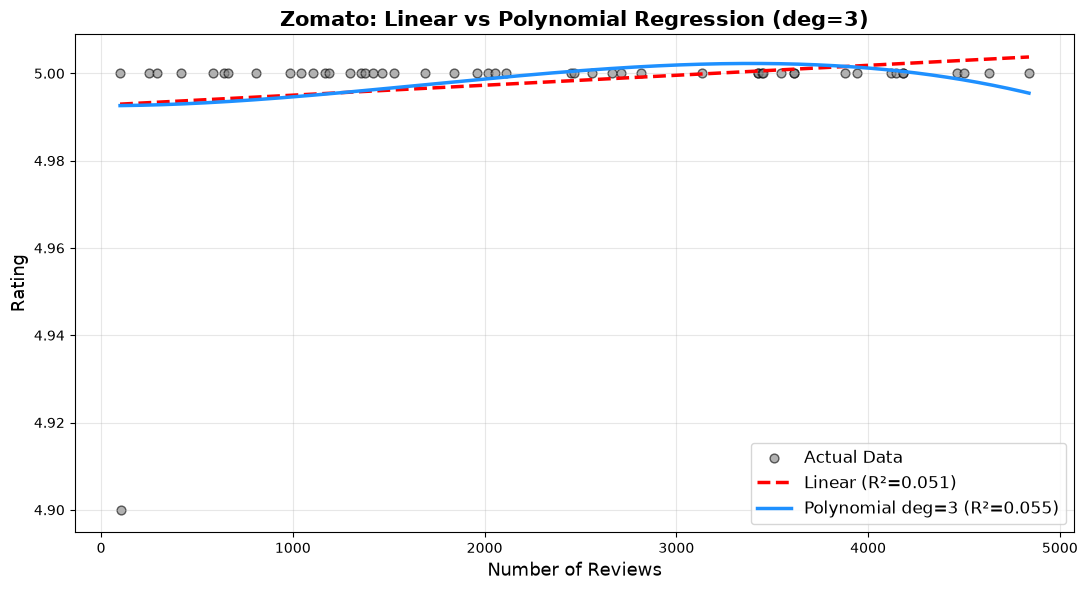

In [5]:
# Plot both models on the same chart
X_smooth = np.linspace(num_reviews.min(), num_reviews.max(), 300).reshape(-1, 1)

plt.figure(figsize=(11, 6))
plt.scatter(num_reviews, rating, color='gray', alpha=0.6, s=40, edgecolors='black', label='Actual Data')
plt.plot(X_smooth, model_linear.predict(X_smooth), color='red', linewidth=2.5,
         linestyle='--', label=f'Linear (R²={r2_score(y_zom, y_pred_linear):.3f})')
plt.plot(X_smooth, model_poly3.predict(X_smooth), color='dodgerblue', linewidth=2.5,
         label=f'Polynomial deg=3 (R²={r2_score(y_zom, y_pred_poly3):.3f})')

plt.xlabel('Number of Reviews', fontsize=13)
plt.ylabel('Rating', fontsize=13)
plt.title('Zomato: Linear vs Polynomial Regression (deg=3)', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observation
- The **red dashed line** (Linear) tries to fit a straight line — but the data has a **curve** (ratings rise fast then plateau), so linear underfits.
- The **blue curve** (Polynomial degree=3) captures the non-linear pattern much better and has a higher R².
- Polynomial regression is more flexible and can model curved relationships that linear regression cannot.

---
## Question 3
**Given a dataset where the relationship between followers and posts for Instagram users is non-linear, fit a polynomial regression model (degree=4) and check for overfitting by plotting the training and validation errors for degrees 1 to 5.**

In [6]:
# ============================================================
# Instagram Dataset: Posts vs Followers (non-linear)
# ============================================================

np.random.seed(25)
n = 60

posts = np.sort(np.random.randint(10, 1000, n)).astype(float)

# Followers grow non-linearly with posts (sqrt-like curve + noise)
followers = 200 * np.sqrt(posts) + 5 * posts + np.random.normal(0, 500, n)
followers = np.clip(followers, 100, 50000).astype(int)

df_insta = pd.DataFrame({'posts': posts, 'followers': followers})
print("✅ Instagram Dataset Created")
print(f"Shape: {df_insta.shape}")
df_insta.head(10)

✅ Instagram Dataset Created
Shape: (60, 2)


,posts,followers
0,98.0,2256
1,116.0,2455
2,119.0,2803
3,141.0,4315
4,142.0,3482
5,146.0,3887
6,153.0,3361
7,161.0,3760
8,166.0,3702
9,170.0,3439


In [7]:
from sklearn.model_selection import train_test_split

X_insta = posts.reshape(-1, 1)
y_insta = followers

# Split 70/30
X_tr, X_val, y_tr, y_val = train_test_split(X_insta, y_insta, test_size=0.3, random_state=42)

# Fit polynomial regression for degrees 1 to 5, track train & validation RMSE
degrees = range(1, 6)
train_errors = []
val_errors = []

for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(X_tr, y_tr)

    train_rmse = np.sqrt(mean_squared_error(y_tr, model.predict(X_tr)))
    val_rmse   = np.sqrt(mean_squared_error(y_val, model.predict(X_val)))

    train_errors.append(train_rmse)
    val_errors.append(val_rmse)

# Print table
print("TRAIN vs VALIDATION RMSE for Degrees 1–5")
print("=" * 50)
print(f"{'Degree':<10} {'Train RMSE':<18} {'Val RMSE':<18} {'Status'}")
print("-" * 60)
for d, tr, va in zip(degrees, train_errors, val_errors):
    gap = va - tr
    if gap > 500:
        status = '⚠️ Overfitting'
    elif tr > 1500:
        status = '⚠️ Underfitting'
    else:
        status = '✅ Good'
    print(f"{d:<10} {tr:<18.2f} {va:<18.2f} {status}")

TRAIN vs VALIDATION RMSE for Degrees 1–5
Degree     Train RMSE         Val RMSE           Status
------------------------------------------------------------
1          476.87             557.96             ✅ Good
2          475.97             553.45             ✅ Good
3          528.91             597.03             ✅ Good
4          659.92             710.49             ✅ Good
5          815.45             874.86             ✅ Good


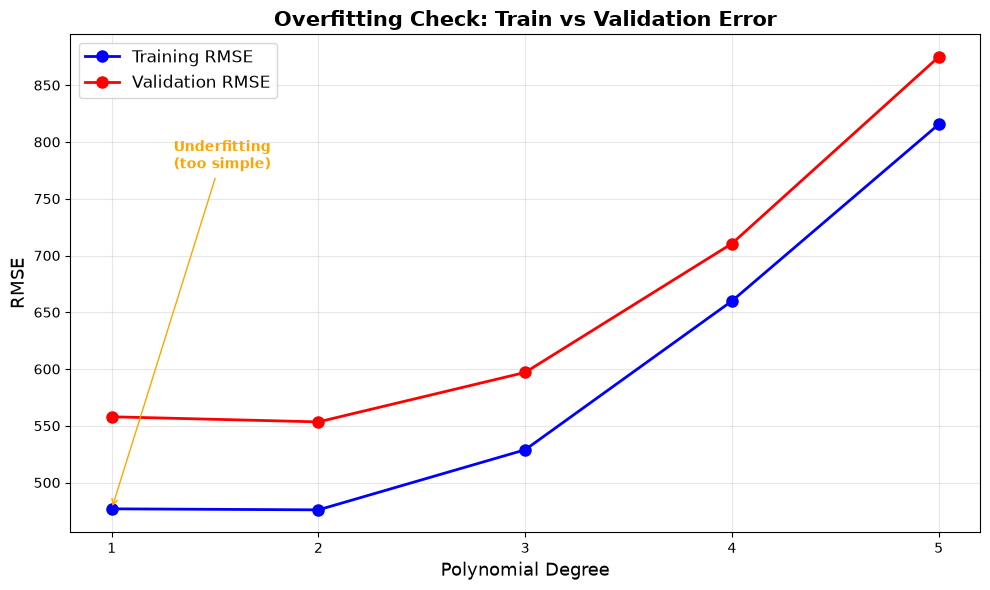

In [8]:
# Plot Train vs Validation Error
plt.figure(figsize=(10, 6))
plt.plot(list(degrees), train_errors, 'bo-', linewidth=2, markersize=8, label='Training RMSE')
plt.plot(list(degrees), val_errors, 'ro-', linewidth=2, markersize=8, label='Validation RMSE')

plt.xlabel('Polynomial Degree', fontsize=13)
plt.ylabel('RMSE', fontsize=13)
plt.title('Overfitting Check: Train vs Validation Error', fontsize=15, fontweight='bold')
plt.xticks(list(degrees))
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

# Annotate
plt.annotate('Underfitting\n(too simple)', xy=(1, train_errors[0]), fontsize=10,
             xytext=(1.3, train_errors[0] + 300),
             arrowprops=dict(arrowstyle='->', color='orange'),
             color='orange', fontweight='bold')

plt.tight_layout()
plt.show()

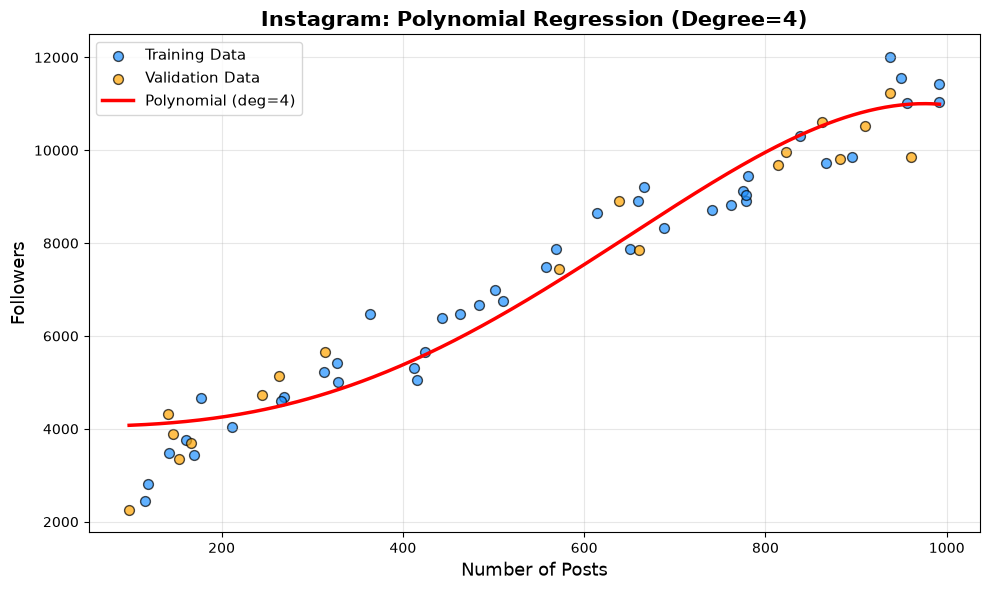

In [9]:
# Fit degree=4 and plot the curve
model_deg4 = make_pipeline(PolynomialFeatures(4), LinearRegression())
model_deg4.fit(X_tr, y_tr)

X_smooth = np.linspace(posts.min(), posts.max(), 300).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X_tr, y_tr, color='dodgerblue', s=50, edgecolors='black', label='Training Data', alpha=0.7)
plt.scatter(X_val, y_val, color='orange', s=50, edgecolors='black', label='Validation Data', alpha=0.7)
plt.plot(X_smooth, model_deg4.predict(X_smooth), color='red', linewidth=2.5,
         label=f'Polynomial (deg=4)')
plt.xlabel('Number of Posts', fontsize=13)
plt.ylabel('Followers', fontsize=13)
plt.title('Instagram: Polynomial Regression (Degree=4)', fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observation
- **Degree 1** (Linear): High train AND validation error → **underfitting** (too simple for curved data).
- **Degree 2–3**: Both errors decrease → model is learning the pattern well → **good fit**.
- **Degree 4–5**: Training error keeps dropping but validation error may **increase or stagnate** → signs of **overfitting** (model starts memorizing training noise).
- The ideal degree is where the **validation error is lowest** — the gap between train and validation error should be small.

---
## Question 4
**Add L2 regularization (Ridge regression) to your polynomial regression model (degree=3) on a Flipkart product price prediction dataset, and compare the model's performance with and without regularization.**

*Hint: Use `Ridge` from `sklearn.linear_model` and explain any difference in test error.*

In [10]:
# ============================================================
# Flipkart Product Price Dataset
# ============================================================

np.random.seed(33)
n = 80

rating       = np.round(np.clip(np.random.normal(4.0, 0.5, n), 1.5, 5.0), 1)
num_reviews  = np.random.randint(50, 50000, n)
discount_pct = np.random.randint(5, 70, n)
seller_score = np.round(np.random.uniform(3.0, 5.0, n), 1)

# Price — non-linear relationship
price = (
    3000 * rating**2 +
    0.1 * num_reviews +
    -80 * discount_pct +
    500 * seller_score +
    np.random.normal(0, 3000, n)
)
price = np.clip(price.astype(int), 499, 99999)

df_flip = pd.DataFrame({
    'rating': rating, 'num_reviews': num_reviews,
    'discount_pct': discount_pct, 'seller_score': seller_score,
    'price': price
})

print("✅ Flipkart Product Dataset Created")
print(f"Shape: {df_flip.shape}")
df_flip.head(10)

✅ Flipkart Product Dataset Created
Shape: (80, 5)


,rating,num_reviews,discount_pct,seller_score,price
0,3.8,6282,38,3.5,44495
1,3.2,13402,20,5.0,35118
2,3.2,39992,48,4.0,33301
3,3.7,16699,69,3.3,39007
4,3.9,28842,15,4.9,49413
5,4.1,6641,31,4.8,52039
6,3.9,45606,49,4.3,53539
7,5.0,11832,14,3.1,76240
8,4.0,33086,27,3.9,46522
9,4.2,49465,41,3.9,59207


In [11]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

features_flip = ['rating', 'num_reviews', 'discount_pct', 'seller_score']
X_flip = df_flip[features_flip].values
y_flip = df_flip['price'].values

X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(X_flip, y_flip, test_size=0.2, random_state=42)

# --- Model A: Polynomial (degree=3) WITHOUT regularization ---
pipe_no_reg = make_pipeline(
    PolynomialFeatures(degree=3),
    StandardScaler(),
    LinearRegression()
)
pipe_no_reg.fit(X_tr_f, y_tr_f)

y_pred_train_A = pipe_no_reg.predict(X_tr_f)
y_pred_test_A  = pipe_no_reg.predict(X_te_f)

# --- Model B: Polynomial (degree=3) WITH Ridge (L2) regularization ---
pipe_ridge = make_pipeline(
    PolynomialFeatures(degree=3),
    StandardScaler(),
    Ridge(alpha=100)     # L2 regularization strength
)
pipe_ridge.fit(X_tr_f, y_tr_f)

y_pred_train_B = pipe_ridge.predict(X_tr_f)
y_pred_test_B  = pipe_ridge.predict(X_te_f)

# Comparison
print("COMPARISON: Without vs With Ridge Regularization")
print("=" * 70)
print(f"{'Metric':<20} {'Poly (No Reg)':<25} {'Poly + Ridge (α=100)'}")
print("=" * 70)
print(f"{'Train R²':<20} {r2_score(y_tr_f, y_pred_train_A):<25.4f} {r2_score(y_tr_f, y_pred_train_B):.4f}")
print(f"{'Test R²':<20} {r2_score(y_te_f, y_pred_test_A):<25.4f} {r2_score(y_te_f, y_pred_test_B):.4f}")
print(f"{'Train RMSE':<20} ₹{np.sqrt(mean_squared_error(y_tr_f, y_pred_train_A)):<25,.0f} ₹{np.sqrt(mean_squared_error(y_tr_f, y_pred_train_B)):,.0f}")
print(f"{'Test RMSE':<20} ₹{np.sqrt(mean_squared_error(y_te_f, y_pred_test_A)):<25,.0f} ₹{np.sqrt(mean_squared_error(y_te_f, y_pred_test_B)):,.0f}")
print("=" * 70)

COMPARISON: Without vs With Ridge Regularization
Metric               Poly (No Reg)             Poly + Ridge (α=100)
Train R²             0.9782                    0.8950
Test R²              0.8855                    0.9072
Train RMSE           ₹1,797                     ₹3,947
Test RMSE            ₹3,831                     ₹3,448


In [12]:
# Compare coefficient magnitudes
coeffs_no_reg = pipe_no_reg.named_steps['linearregression'].coef_
coeffs_ridge  = pipe_ridge.named_steps['ridge'].coef_

print(f"\nCOEFFICIENT MAGNITUDE COMPARISON")
print(f"{'='*50}")
print(f"{'Metric':<30} {'No Reg':<15} {'Ridge'}")
print(f"{'-'*50}")
print(f"{'Num coefficients':<30} {len(coeffs_no_reg):<15} {len(coeffs_ridge)}")
print(f"{'Max |coefficient|':<30} {np.max(np.abs(coeffs_no_reg)):<15.2f} {np.max(np.abs(coeffs_ridge)):.2f}")
print(f"{'Mean |coefficient|':<30} {np.mean(np.abs(coeffs_no_reg)):<15.2f} {np.mean(np.abs(coeffs_ridge)):.2f}")
print(f"{'Sum |coefficient|':<30} {np.sum(np.abs(coeffs_no_reg)):<15.2f} {np.sum(np.abs(coeffs_ridge)):.2f}")
print(f"\n✅ Ridge shrank the coefficients → more stable, less overfitting.")


COEFFICIENT MAGNITUDE COMPARISON
Metric                         No Reg          Ridge
--------------------------------------------------
Num coefficients               35              35
Max |coefficient|              246121.73       1885.92
Mean |coefficient|             58451.70        420.88
Sum |coefficient|              2045809.43      14730.90

✅ Ridge shrank the coefficients → more stable, less overfitting.


### Explanation

**Ridge Regression (L2 Regularization)** adds a penalty to the loss function:

$$\text{Loss} = \sum(y_i - \hat{y}_i)^2 + \alpha \sum \beta_j^2$$

| Aspect | Without Regularization | With Ridge (α=100) |
|--------|----------------------|--------------------|
| **Train R²** | Higher (fits training data closely) | Slightly lower (intentionally constrained) |
| **Test R²** | May be lower (overfits to train) | Often higher (generalizes better) |
| **Coefficients** | Can be very large and unstable | Shrunk toward zero → more stable |
| **Overfitting** | More prone | Less prone |

- The **α (alpha)** parameter controls regularization strength: higher α → more shrinkage.
- Ridge **does NOT eliminate features** — it shrinks them. For feature elimination, use Lasso (L1).

---
## Question 5
**Use ChatGPT or Copilot to generate Python code that demonstrates underfitting and overfitting using polynomial regression on a synthetic dataset, then run the code and explain in your own words how model degree affects bias and variance.**

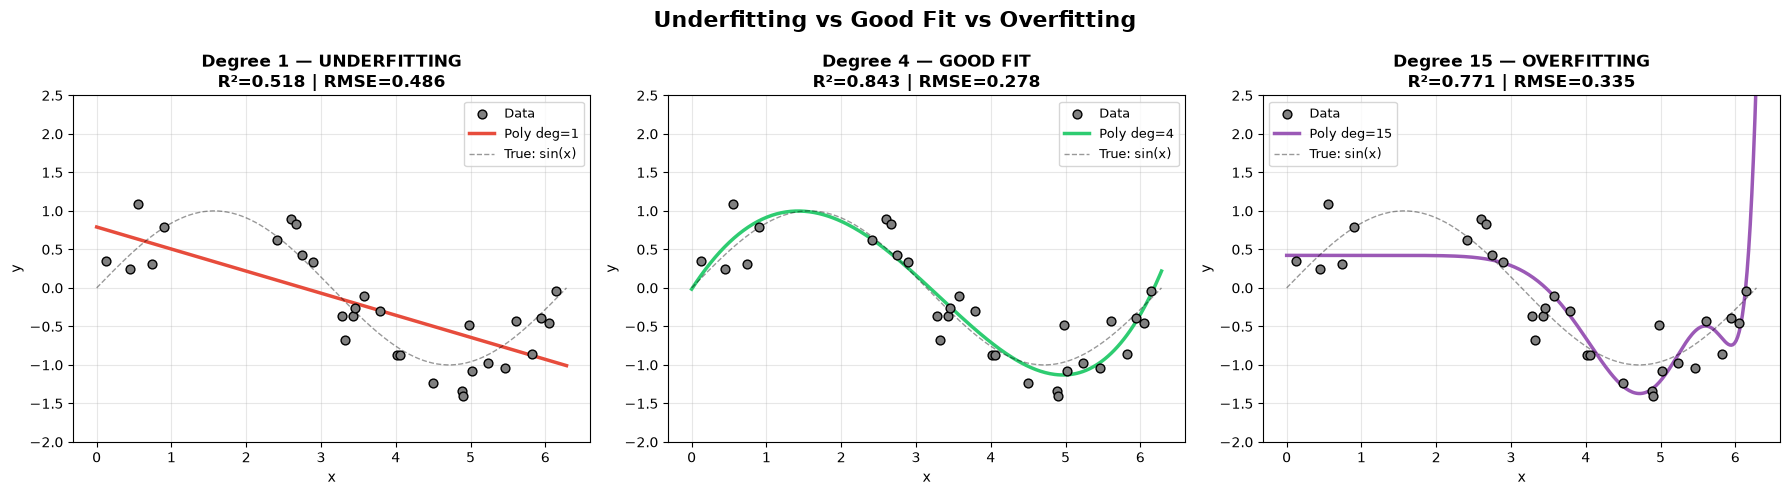

In [13]:
# ============================================================
# Generated Code: Underfitting vs Overfitting Demo
# (Using Polynomial Regression on synthetic data)
# ============================================================

np.random.seed(0)

# Generate synthetic non-linear data: y = sin(x) + noise
X_syn = np.sort(np.random.uniform(0, 2 * np.pi, 30))
y_syn = np.sin(X_syn) + np.random.normal(0, 0.25, 30)

X_syn_2d = X_syn.reshape(-1, 1)
X_plot = np.linspace(0, 2 * np.pi, 300).reshape(-1, 1)

# Fit models with degree = 1 (underfit), 4 (good), 15 (overfit)
degrees_demo = [1, 4, 15]
titles = ['Degree 1 — UNDERFITTING', 'Degree 4 — GOOD FIT', 'Degree 15 — OVERFITTING']
colors = ['#e74c3c', '#2ecc71', '#9b59b6']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, deg, title, color in zip(axes, degrees_demo, titles, colors):
    model = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    model.fit(X_syn_2d, y_syn)

    y_plot = model.predict(X_plot)

    train_r2 = r2_score(y_syn, model.predict(X_syn_2d))
    train_rmse = np.sqrt(mean_squared_error(y_syn, model.predict(X_syn_2d)))

    ax.scatter(X_syn, y_syn, color='gray', s=40, edgecolors='black', zorder=5, label='Data')
    ax.plot(X_plot, y_plot, color=color, linewidth=2.5, label=f'Poly deg={deg}')
    ax.plot(X_plot, np.sin(X_plot), 'k--', linewidth=1, alpha=0.4, label='True: sin(x)')

    ax.set_title(f'{title}\nR²={train_r2:.3f} | RMSE={train_rmse:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=9)
    ax.set_ylim(-2, 2.5)
    ax.grid(alpha=0.3)

plt.suptitle('Underfitting vs Good Fit vs Overfitting', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

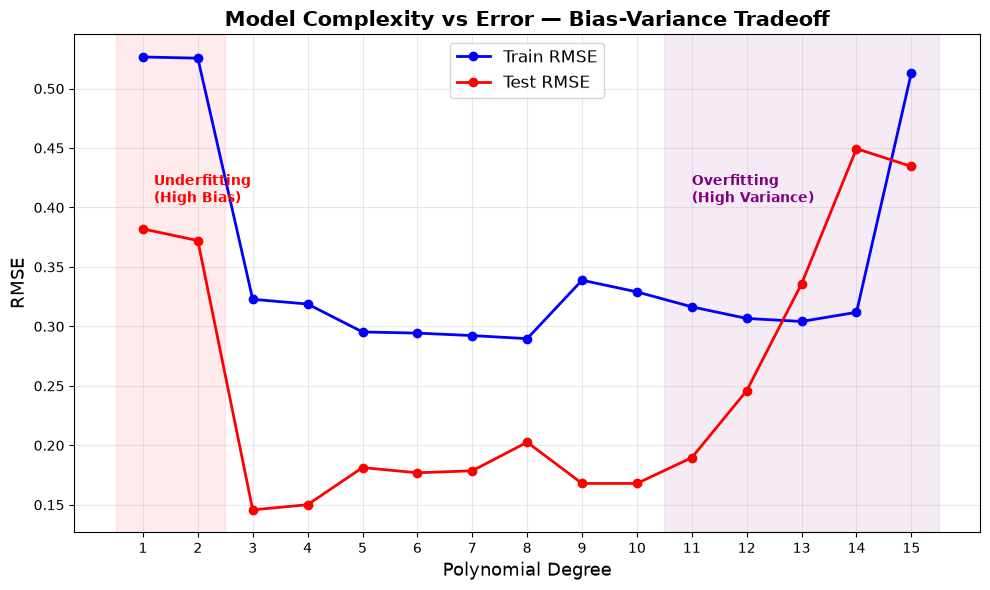

In [14]:
# Train vs Test error across degrees 1–15
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_syn_2d, y_syn, test_size=0.3, random_state=42)

all_degrees = range(1, 16)
train_rmses = []
test_rmses = []

for d in all_degrees:
    m = make_pipeline(PolynomialFeatures(d), LinearRegression())
    m.fit(X_tr_s, y_tr_s)
    train_rmses.append(np.sqrt(mean_squared_error(y_tr_s, m.predict(X_tr_s))))
    test_rmses.append(np.sqrt(mean_squared_error(y_te_s, m.predict(X_te_s))))

plt.figure(figsize=(10, 6))
plt.plot(list(all_degrees), train_rmses, 'bo-', linewidth=2, label='Train RMSE')
plt.plot(list(all_degrees), test_rmses, 'ro-', linewidth=2, label='Test RMSE')
plt.xlabel('Polynomial Degree', fontsize=13)
plt.ylabel('RMSE', fontsize=13)
plt.title('Model Complexity vs Error — Bias-Variance Tradeoff', fontsize=15, fontweight='bold')
plt.xticks(list(all_degrees))
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

# Annotate regions
plt.axvspan(0.5, 2.5, alpha=0.08, color='red', label='Underfitting')
plt.axvspan(10.5, 15.5, alpha=0.08, color='purple', label='Overfitting')
plt.text(1.2, max(test_rmses)*0.9, 'Underfitting\n(High Bias)', fontsize=10, color='red', fontweight='bold')
plt.text(11, max(test_rmses)*0.9, 'Overfitting\n(High Variance)', fontsize=10, color='purple', fontweight='bold')

plt.tight_layout()
plt.show()

### Explanation: How Model Degree Affects Bias and Variance

| Degree | Bias | Variance | What Happens |
|--------|------|----------|-------------|
| **Low (1–2)** | **High** | Low | The model is too simple — a straight line can't capture the sine curve. It **underfits**: it performs poorly on BOTH train and test data because it makes overly rigid assumptions. |
| **Medium (3–5)** | **Low** | Low | The model has just the right complexity to capture the true curve without memorizing noise. This is the **sweet spot** — good performance on both train and test data. |
| **High (10–15)** | Low | **High** | The model becomes so flexible that it starts fitting the **noise** in the training data, creating wild oscillations between points. It **overfits**: train error is near-zero but test error skyrockets because the model memorized training noise instead of learning the true pattern. |

**In my own words:**

As the polynomial degree increases, the model gains more "flexibility" to bend and curve through data points. At **degree 1**, the model is like a ruler — rigid and unable to capture curves (high bias, underfitting). At **degree 4**, it has just enough flexibility to trace the sine wave's shape without overreacting to noise — this is the optimal balance. But at **degree 15**, the model has SO much flexibility that it passes through almost every training point, including the random noise. It looks perfect on training data (low bias) but performs terribly on new data because it learned noise, not the real pattern (high variance, overfitting). This is the **bias-variance tradeoff** — reducing one increases the other, and the goal is to find the middle ground.